# C: AMN growth and MINN flux transfer

One frozen C FluxTransformer is shared across independently trained front MLPs. AMN uses a medium-to-growth MLP. MINN trains two independent omics-to-context MLPs: measured and predicted glucose/oxygen context. Each outer fold starts a fresh MLP. Both MINN variants use observed glucose/oxygen bounds in downstream pFBA.

The notebook contains no generic tabular-model benchmark. Run from the repository root using its Python environment. The local model C checkpoint is configured below; command provenance is optional. MINN runs one 50-trial, five-fold HPO study per context mode, then 29 leave-one-out fits with the selected parameters. Outputs remain empty until you execute it.

Implementation helpers: `iml1515_evaluation.py`. Protocol: `docs/working_notes/iML1515_C_notebook_notes.md`. Historical A/B/C scores require matched reruns before comparison.

In [1]:
import os
import numpy as np
import seaborn as sns
from pathlib import Path
from datetime import datetime, timezone
import importlib.metadata
import subprocess

import pandas as pd
import matplotlib.pyplot as plt
import torch
from IPython.display import display

import iml1515_evaluation as ev

ROOT = Path.cwd()
if not (ROOT / "flux_transformer.py").is_file():
    raise RuntimeError("Start the notebook in the metabolic-NN repository root.")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cuda


## Run configuration

The local model C checkpoint, training log and biomass test CSV are selected below. Run the notebook from the repository root. Generation/training command fields are optional documentation and may remain empty. A missing optional log or biomass CSV does not prevent AMN/MINN evaluation.

The checkpoint loss curves and biomass-only diagnostic appear before experimental training. Full A/B simulated fidelity is disabled by default; enable it only when you want that additional analysis and have set its test paths. Optional MINN target-file and cap-set sensitivities retain both context modes.

In [2]:
MODEL_FAMILY = "C"
CHECKPOINT = ROOT / "models/AMN_MINN_1M_d256_h8_l4_ff1024/AMN_MINN_1M_d256_h8_l4_ff1024_checkpoint.pth"
TRAINING_LOG = ROOT / "models/AMN_MINN_1M_d256_h8_l4_ff1024/AMN_MINN_1M_d256_h8_l4_ff1024_training.log"
METADATA_JSON = None  # Only needed if the checkpoint lacks config/data_info.
TRAINING_PROVENANCE = {"generation_command": "", "training_command": "", "seed": 42}

RUN_SIMULATED = False  # Optional full A/B fidelity analysis.
BIOMASS_TEST_PATH = ROOT / "data/iML1515_AMN_MINN_test_data_50000_samples.csv"
BIOMASS_BATCH_SIZE = 2
RUN_AMN = True
RUN_MINN = True
TARGET_MODES = ["minn_fitted"]  # Optional: "non_fitted", "iml1515_minn_like".
CAP_MODES = ["co2_etoh_ac_cap"]  # Optional additional sensitivity: "etoh_ac_cap".
SIMULATED = {
    "A": {"path": None, "seed": 9, "rows": 50000, "command": ""},
    "B": {"path": None, "seed": 9, "rows": 50000, "command": ""},
}
SIM_BATCH_SIZE = 2
OBJECTIVE_CHECK_SAMPLES = 100  # First 100 rows/domain
# All rows get mass/bound checks.
PFBA_FRACTION = 1.0  # Match model C downstream pFBA.
XML_PATH = ROOT / "models/iML1515.xml"
AMN_DIR, MINN_DIR = ROOT / "AMN_data", ROOT / "MINN_data"

AMN_SETTINGS = dict(folds=10, split_seeds=[10, 11, 12], train_seed=10,
    inner_fraction=0.2, hidden=512, epochs=100, patience=15, min_delta=0.0,
    batch_size=1, delta=0.03, clip=1.0, amp=False, warmup=0,
    params={"drop_rate": 0.0, "learning_rate": 1e-3, "weight_decay": 1e-3})
MINN_SETTINGS = dict(seed=12345, inner_folds=5, trials=50, hidden=512,
    epochs=150, patience=25, min_delta=1e-5, batch_size=2, delta=1.0,
    clip=1.0, amp=False, warmup=10, std_penalty=0.25,
    drop_rates=[0.0, 0.05, 0.1, 0.2, 0.3, 0.35, 0.4],
    lr_range=[5e-4, 1e-2], wd_range=[1e-8, 1e-3])
# Use a new directory for every execution
# Completed folds are saved immediately.
RUN_ID = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")


In [3]:
required = {"CHECKPOINT": CHECKPOINT, "XML": XML_PATH}
if TRAINING_LOG is not None and Path(TRAINING_LOG).is_file():
    required["TRAINING_LOG"] = TRAINING_LOG
if BIOMASS_TEST_PATH is not None and Path(BIOMASS_TEST_PATH).is_file():
    required["biomass_test"] = BIOMASS_TEST_PATH
if METADATA_JSON is not None:
    required["METADATA_JSON"] = METADATA_JSON
if RUN_AMN:
    required.update({name: AMN_DIR / name for name in ("iML1515_EXP.csv", "EXP110.csv")})
if RUN_MINN:
    if not TARGET_MODES or len(set(TARGET_MODES)) != len(TARGET_MODES):
        raise ValueError("Specify unique MINN target modes.")
    if "co2_etoh_ac_cap" not in CAP_MODES or not set(CAP_MODES) <= {"co2_etoh_ac_cap", "etoh_ac_cap"}:
        raise ValueError("Keep the primary CO2/ethanol/acetate cap comparison enabled.")
    required.update({name: MINN_DIR / name for name in ("transcriptomics.csv", "proteomics.csv")})
    required.update({mode: MINN_DIR / ev.FLUX_FILES[mode] for mode in TARGET_MODES})
if RUN_SIMULATED:
    required.update({f"simulated_{key}": spec["path"] for key, spec in SIMULATED.items()})
missing = [name for name, path in required.items() if path is None or not Path(path).is_file()]
if missing:
    raise FileNotFoundError("Configure/provide these inputs before running: " + ", ".join(missing))
if RUN_SIMULATED and any(s["seed"] is not None and s["seed"] == TRAINING_PROVENANCE["seed"] for s in SIMULATED.values()):
    raise ValueError("Held-out generation seed must differ from the training seed.")

reservoir, input_names, output_names, architecture, training_info = ev.load_reservoir(CHECKPOINT, DEVICE, METADATA_JSON, model_family=MODEL_FAMILY)
model_name = Path(CHECKPOINT).parent.name
run_dir = ROOT / "pics" / model_name / "C_evaluation" / RUN_ID
run_dir.mkdir(parents=True, exist_ok=False)
pic_dir = run_dir / "figures"
pic_dir.mkdir()
print("Architecture:", architecture)
print("Inputs:", len(input_names), "Outputs:", len(output_names))
print("Artifacts:", run_dir)


Architecture: {'d_model': 256, 'n_heads': 8, 'n_layers': 4, 'd_ff': 1024, 'dropout': 0.02, 'batch_size': 32, 'learning_rate': 0.0001, 'num_epochs': 13, 'requested_num_epochs': 15, 'training_end_epoch': 15, 'patience': 3, 'vocab_size': 2712, 'input_token_indices': [180, 1981, 45, 1525, 106, 40, 86, 92, 104, 164, 304, 621, 700, 859, 913, 934, 970, 1424, 1478, 1485, 1500, 1534, 1535, 1836, 2243, 2320, 99, 108, 98, 1490, 217, 114, 1439, 288, 303, 206, 209, 347, 112, 111], 'output_sample_ratio': 1.0}
Inputs: 40 Outputs: 2712
Artifacts: c:\Users\truok\projects\metabolic-NN\pics\AMN_MINN_1M_d256_h8_l4_ff1024\C_evaluation\20260915T024826709856Z


In [4]:
manifest = {
    "model_family": MODEL_FAMILY, "run_id": RUN_ID, "checkpoint": str(CHECKPOINT), "architecture": architecture,
    "training_info": training_info, "training_provenance": TRAINING_PROVENANCE,
    "inputs": input_names, "outputs": output_names, "device": str(DEVICE),
    "objective": ev.OBJECTIVE, "pfba_fraction": PFBA_FRACTION,
    "amn_settings": AMN_SETTINGS, "minn_settings": MINN_SETTINGS,
    "target_modes": TARGET_MODES, "cap_modes": CAP_MODES, "simulated_specs": SIMULATED,
    "objective_check_samples": OBJECTIVE_CHECK_SAMPLES,
    "versions": {p: importlib.metadata.version(p) for p in ("torch", "numpy", "pandas", "scikit-learn", "cobra", "optuna")},
    "files": {name: {"path": str(path), "sha256": ev.file_hash(path)} for name, path in required.items()},
    "code_hashes": {name: ev.file_hash(ROOT / name) for name in
        ("iml1515_evaluation.py", "flux_transformer.py", "generate_ecoli_iML1515_AMN_MINN_data.py", "ecoli_iML1515_C_model_testing.ipynb")},
    "git_revision": subprocess.run(["git", "rev-parse", "HEAD"], capture_output=True, text=True).stdout.strip(),
    "status": "started", "deferred": ["C/intermediate fidelity", "broad D/E fidelity", "embedding exploration"],
}
ev.save_json(run_dir / "manifest.json", manifest)
# No automatic cache loading: fresh run directories prevent stale-mode/result reuse.
amn_result, minn_data, minn_results, pfba_results = None, {}, {}, {}
simulated_summary = None


## Checkpoint loss curves and biomass diagnostic

These use the same plotting functions and style as the earlier AMN notebook: a logarithmic loss graph and a 2?2 biomass diagnostic (true versus predicted, residuals, error distribution, and true-value distribution). The saved checkpoint calls its held-out loss `test_losses`; it is labelled Validation Loss here. Only biomass is plotted. Full-vocabulary inference is retained.


In [5]:
def plot_loss_curves(train_losses, test_losses, d_model, n_heads, n_layers, d_ff, save_path=None, log_scale=True):
    plt.figure(figsize=(14, 10))
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.plot(train_losses, label="Training Loss")
    plt.plot(test_losses, label="Validation Loss")
    if log_scale:
        plt.yscale('log')
    plt.xlabel("Epoch", fontsize=18)
    plt.ylabel("Loss", fontsize=18)
    plt.title(f"Loss Curves (d={d_model}, h={n_heads}, l={n_layers}, ff={d_ff})", fontsize=20)
    plt.grid(True)
    plt.legend(fontsize=16)
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path)
        plt.show()
        print(f"\nTraining curve saved to {save_path}")
    else:
        plt.show()

def plot_diagnostics_2x2(y_true, y_pred, label, save_path=None):
    """Creates a 2x2 matrix of plots: true vs predicted, residuals, error distribution, and histogram of samples."""
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    residuals = y_true - y_pred
    display_label = str(label)
    if display_label.endswith('_flux'):
        display_label = display_label[:-5]
    if display_label.upper().startswith('BIOMASS'):
        display_label = 'Model C iML1515 Biomass'

    title_fs = 15
    label_fs = 13
    tick_fs = 11

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    # True vs Predicted
    axs[0, 0].scatter(y_true, y_pred, alpha=0.2, s=5, color='royalblue')
    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())
    axs[0, 0].plot([lo, hi], [lo, hi], 'k--', lw=2)
    axs[0, 0].set_title(f'True vs Predicted: {display_label}', fontsize=title_fs)
    axs[0, 0].set_xlabel('True value', fontsize=label_fs)
    axs[0, 0].set_ylabel('Predicted', fontsize=label_fs)
    axs[0, 0].grid(True)

    # Residuals plot
    axs[0, 1].scatter(y_true, residuals, alpha=0.15, color='darkorange')
    axs[0, 1].axhline(y=0, color='r', linestyle='-')
    axs[0, 1].set_title(f'Residuals: {display_label}', fontsize=title_fs)
    axs[0, 1].set_xlabel('True value', fontsize=label_fs)
    axs[0, 1].set_ylabel('Residuals', fontsize=label_fs)
    if str(label).upper().startswith('BIOMASS'):
        axs[0, 1].set_ylim(-0.05, 0.05)
    else:
        res_abs_max = float(np.nanmax(np.abs(residuals))) if residuals.size else 1.0
        if (not np.isfinite(res_abs_max)) or (res_abs_max == 0.0):
            res_abs_max = 1.0
        axs[0, 1].set_ylim(-res_abs_max, res_abs_max)
    axs[0, 1].grid(True)

    # Error distribution
    sns.histplot(residuals, kde=True, ax=axs[1, 0], legend=False, color='indianred')
    axs[1, 0].set_title(f'Prediction Error Distribution: {display_label}', fontsize=title_fs)
    axs[1, 0].set_xlabel('Prediction Error', fontsize=label_fs)
    axs[1, 0].set_ylabel('Frequency', fontsize=label_fs)
    axs[1, 0].grid(True)

    # Histogram of actual values
    sns.histplot(y_true, kde=True, bins=100, ax=axs[1, 1], legend=False, color='mediumseagreen')
    axs[1, 1].set_title(f'True Value Distribution: {display_label}', fontsize=title_fs)
    axs[1, 1].set_xlabel('True Value', fontsize=label_fs)
    axs[1, 1].set_ylabel('Frequency', fontsize=label_fs)
    axs[1, 1].grid(True)

    for ax in axs.ravel():
        ax.tick_params(labelsize=tick_fs)

    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        plt.show()
        plt.close(fig)
    else:
        plt.show()
        plt.close(fig)

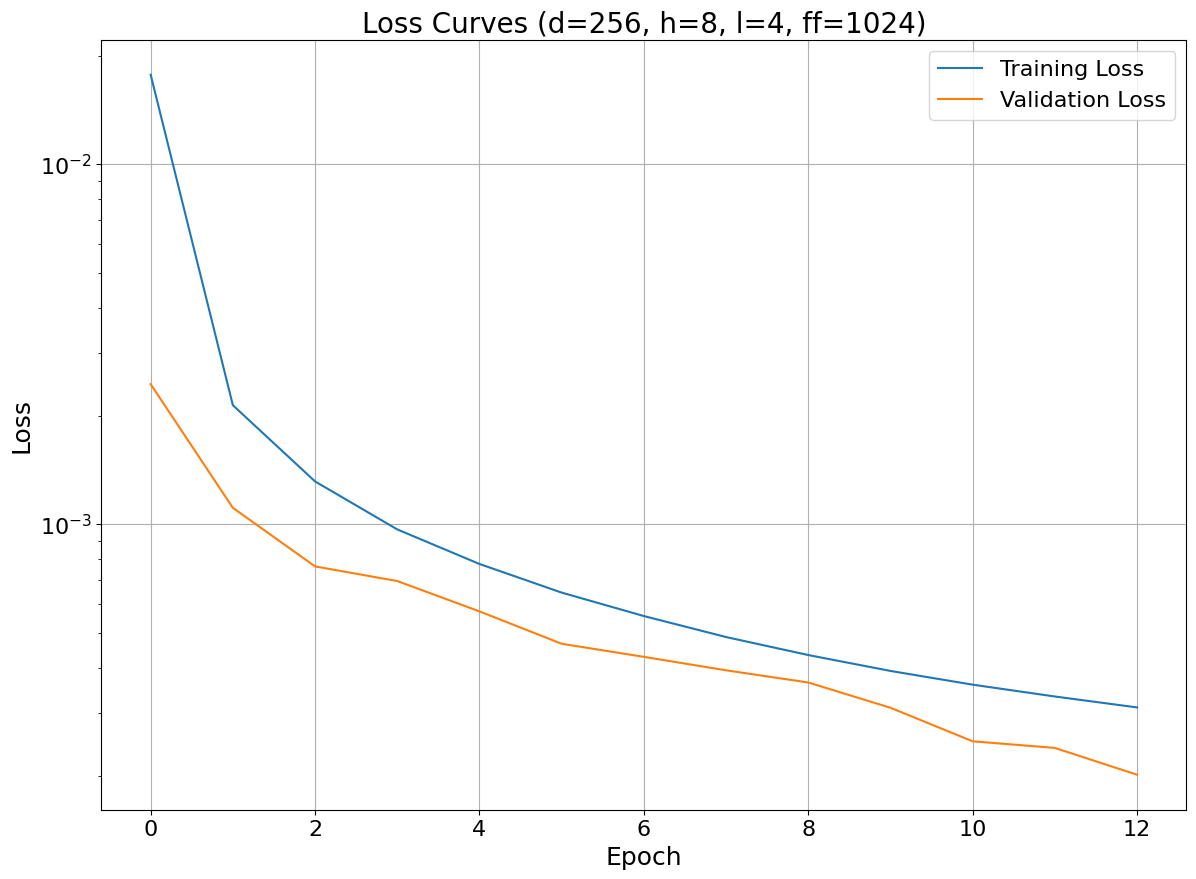


Training curve saved to c:\Users\truok\projects\metabolic-NN\pics\AMN_MINN_1M_d256_h8_l4_ff1024\C_evaluation\20260915T024826709856Z\figures\AMN_MINN_1M_d256_h8_l4_ff1024_loss_curves.png


In [6]:
checkpoint_plot_data = torch.load(CHECKPOINT, map_location="cpu", weights_only=False)
train_losses = checkpoint_plot_data.get("train_losses", [])
validation_losses = checkpoint_plot_data.get("test_losses", [])
del checkpoint_plot_data
if len(train_losses) and len(validation_losses):
    plot_loss_curves(train_losses, validation_losses,
        architecture["d_model"], architecture["n_heads"], architecture["n_layers"], architecture["d_ff"],
        save_path=str(pic_dir / f"{model_name}_loss_curves.png"))
else:
    print("Checkpoint has no saved loss history; loss plot skipped.")


,R2,Pearson_r2,MAE,RMSE,NE
0,0.997204,0.999021,0.007824,0.009716,0.025556


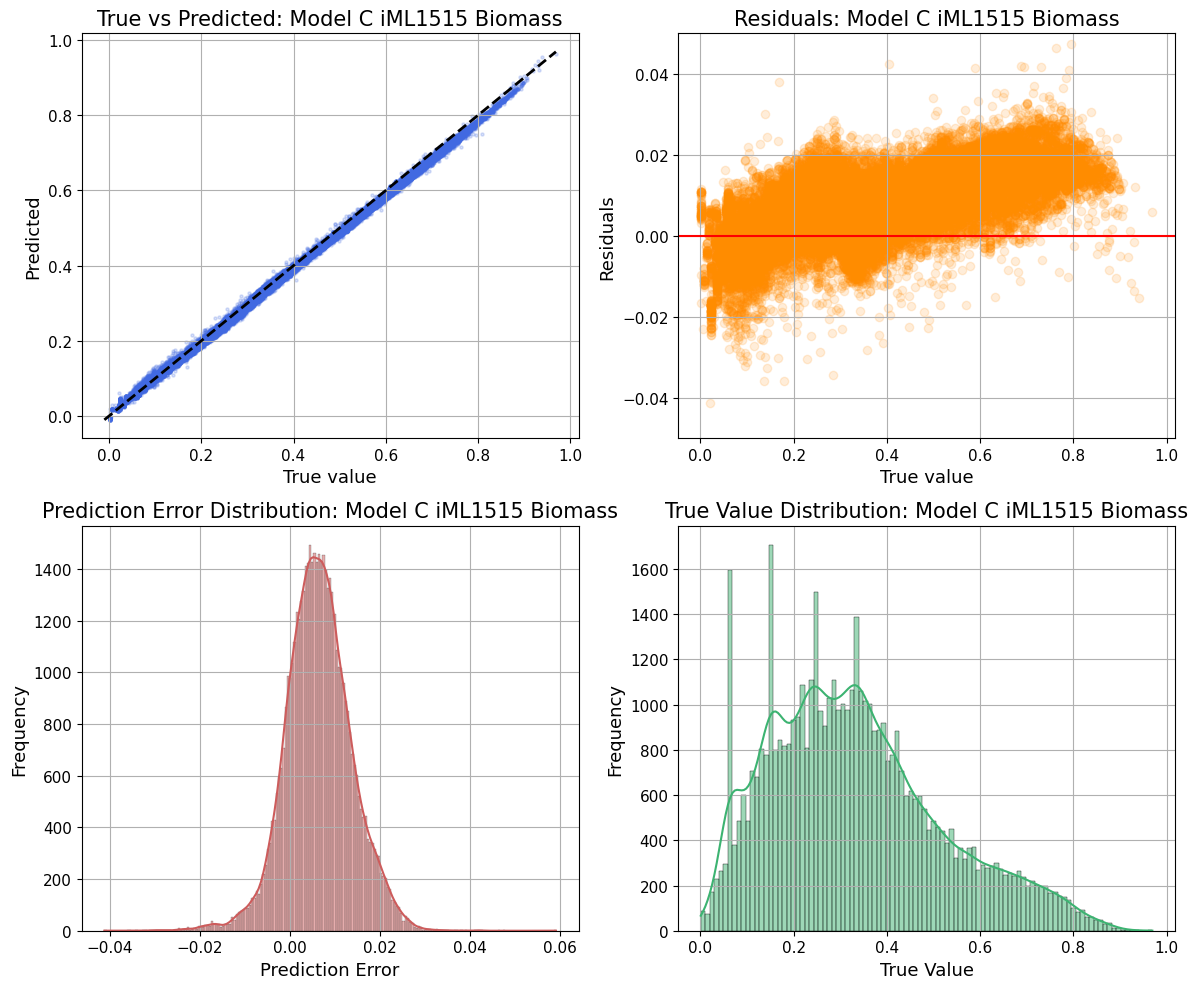

In [7]:
biomass_diagnostic = None
if BIOMASS_TEST_PATH is None or not Path(BIOMASS_TEST_PATH).is_file():
    print("Biomass diagnostic skipped: set BIOMASS_TEST_PATH to an independent simulated test CSV.")
else:
    if Path(BIOMASS_TEST_PATH).resolve() == Path(str(training_info.get("dataset", ""))).resolve():
        raise ValueError("Biomass diagnostics require held-out data, not the training CSV.")
    header = pd.read_csv(BIOMASS_TEST_PATH, nrows=0).columns.tolist()
    if [name for name in header if name.endswith("_flux")] != output_names:
        raise ValueError("Biomass test output order differs from the checkpoint.")
    if [name for name in header if not name.endswith("_flux")] != input_names:
        raise ValueError("Biomass test input order differs from the checkpoint.")
    biomass_token = f"{ev.OBJECTIVE}_flux"
    biomass_index = output_names.index(biomass_token)
    injection = [output_names.index(f"{name}_flux") for name in input_names]
    biomass_truth, biomass_prediction = [], []
    reservoir.eval()
    with torch.inference_mode():
        for frame in pd.read_csv(BIOMASS_TEST_PATH, usecols=input_names + [biomass_token], chunksize=128):
            ev.finite_frame(frame, "Biomass test data")
            medium = frame[input_names].to_numpy(np.float32)
            biomass_truth.extend(frame[biomass_token].to_numpy(float))
            for start in range(0, len(frame), BIOMASS_BATCH_SIZE):
                values = torch.as_tensor(medium[start:start + BIOMASS_BATCH_SIZE], device=DEVICE)
                c = torch.zeros(len(values), len(output_names), 1, device=DEVICE)
                c[:, injection, 0] = values
                predicted, _ = reservoir(c, output_subset=None)
                biomass_prediction.extend(predicted[:, biomass_index, -1].cpu().numpy())
    biomass_diagnostic = pd.DataFrame({"truth": biomass_truth, "prediction": biomass_prediction})
    display(pd.DataFrame([ev.metrics(biomass_truth, biomass_prediction)]))
    biomass_diagnostic.to_csv(run_dir / "biomass_diagnostic.csv", index=False)
    plot_diagnostics_2x2(biomass_truth, biomass_prediction, biomass_token,
        save_path=str(pic_dir / f"{model_name}_biomass_diagnostic.png"))


## Independent simulated-data fidelity

A and B are scored separately, plus an equally weighted pooled score. Full-output inference is mandatory. The helper streams all rows, exports per-flux error/activity and per-row mass-balance/bound diagnostics, and checks objective agreement on the configured subset. A's CO2/acetate uptake semantics and B's secretion-cap semantics remain distinct. The generation commands are part of the recorded provenance.

In [8]:
if RUN_SIMULATED:
    for spec in SIMULATED.values():
        training_path = Path(str(training_info.get("dataset", "")))
        if Path(spec["path"]).resolve() == training_path.resolve():
            raise ValueError("Simulated evaluation path points at the training dataset.")
    simulated_summary = ev.simulated_fidelity(reservoir, input_names, output_names,
        SIMULATED, XML_PATH, run_dir / "simulated", batch_size=SIM_BATCH_SIZE,
        objective_samples=OBJECTIVE_CHECK_SAMPLES, fraction=0.999)
    display(simulated_summary)
else:
    print("Optional full A/B fidelity analysis skipped.")


Optional full A/B fidelity analysis skipped.


## AMN: prepare model C media

The 110 media use base inputs (including CO2) of 50, fixed glycerol/amino acids of 2.2, and absent glucose/ethanol inputs of zero. Cobalamin is supplied at 50 only when it is a checkpoint input; the configured legacy C checkpoint has 40 inputs and excludes it. A masked sigmoid prior predicts the ten carbon rates and oxygen. Carbon rates range from 0 to 2.2; oxygen from 0 to 10. These ranges retain the existing prior parameterization, including values below the simulation's sampling minima. Experimental SD is joined by medium composition and checked against measured growth.

In [9]:
if RUN_AMN:
    amn_data = ev.load_amn(AMN_DIR, input_names=input_names, model_family=MODEL_FAMILY)
    display(pd.DataFrame({"input": list(amn_data["fixed"]), "fixed_value": list(amn_data["fixed"].values())}))
    print("AMN features:", amn_data["features"])
    print("AMN shape:", amn_data["X"].shape)
    ev.save_json(run_dir / "amn_schema.json", {"features": amn_data["features"],
        "targets": amn_data["targets"], "sample_ids": amn_data["ids"].tolist(), "fixed": amn_data["fixed"]})


,input,fixed_value
0,EX_glc__D_e,0.0
1,EX_o2_e,0.0
2,EX_co2_e,50.0
3,EX_etoh_e,0.0
4,EX_ac_e,0.0
5,EX_pi_e,50.0
6,EX_fe3_e,50.0
7,EX_h_e,50.0
8,EX_mn2_e,50.0
9,EX_fe2_e,50.0


AMN features: ['EX_rib__D_e', 'EX_malt_e', 'EX_melib_e', 'EX_tre_e', 'EX_fru_e', 'EX_gal_e', 'EX_ac_e', 'EX_lac__D_e', 'EX_succ_e', 'EX_pyr_e', 'EX_o2_e']
AMN shape: (110, 11)


### Train the AMN MLP under repeated outer CV

Ten folds, stratified by carbon count, repeated with seeds 10/11/12. An inner training-only split selects the epoch count. A fresh MLP is refit on the full outer training set for that count. The outer fold is scored once. This differs from the legacy outer-fold early-stopping protocol, so historical scores are not matched comparisons.

In [10]:
if RUN_AMN:
    amn_result = ev.run_amn(reservoir, output_names, amn_data, AMN_SETTINGS, run_dir / "amn")
    display(amn_result["summary"])
    display(amn_result["summary"].drop(columns="repeat").agg(["mean", lambda x: x.std(ddof=0)]))


AMN repeat 10, fold 1: refit 45 epochs
AMN repeat 10, fold 2: refit 9 epochs
AMN repeat 10, fold 3: refit 8 epochs
AMN repeat 10, fold 4: refit 13 epochs
AMN repeat 10, fold 5: refit 17 epochs
AMN repeat 10, fold 6: refit 9 epochs
AMN repeat 10, fold 7: refit 18 epochs
AMN repeat 10, fold 8: refit 13 epochs
AMN repeat 10, fold 9: refit 3 epochs
AMN repeat 10, fold 10: refit 2 epochs
AMN repeat 11, fold 1: refit 1 epochs
AMN repeat 11, fold 2: refit 17 epochs
AMN repeat 11, fold 3: refit 11 epochs
AMN repeat 11, fold 4: refit 32 epochs
AMN repeat 11, fold 5: refit 24 epochs
AMN repeat 11, fold 6: refit 3 epochs
AMN repeat 11, fold 7: refit 10 epochs
AMN repeat 11, fold 8: refit 10 epochs
AMN repeat 11, fold 9: refit 10 epochs
AMN repeat 11, fold 10: refit 3 epochs
AMN repeat 12, fold 1: refit 11 epochs
AMN repeat 12, fold 2: refit 32 epochs
AMN repeat 12, fold 3: refit 17 epochs
AMN repeat 12, fold 4: refit 3 epochs
AMN repeat 12, fold 5: refit 33 epochs
AMN repeat 12, fold 6: refit 7 e

,repeat,R2,Pearson_r2,MAE,RMSE,NE
0,10,0.776738,0.782979,0.033095,0.039844,0.160752
1,11,0.782997,0.788048,0.032707,0.039282,0.158483
2,12,0.798653,0.799349,0.030425,0.037838,0.152659


,R2,Pearson_r2,MAE,RMSE,NE
mean,0.786129,0.790125,0.032076,0.038988,0.157298
<lambda>,0.009217,0.006843,0.001178,0.000845,0.003409


### AMN growth errors and uncertainty

Model C-style reporting: average OOF predictions per medium, then compute R2, MAE and RMSE across those means. Report population SD of per-repeat metrics separately. Orange horizontal bars show experimental SD; orange vertical bars show prediction SD across repeats (ddof=1). This spread is not a calibrated prediction interval.


,Metric,OOF score,SD across repeats
0,R2,0.812463,0.009217
1,MAE,0.030263,0.001178
2,RMSE,0.036517,0.000845


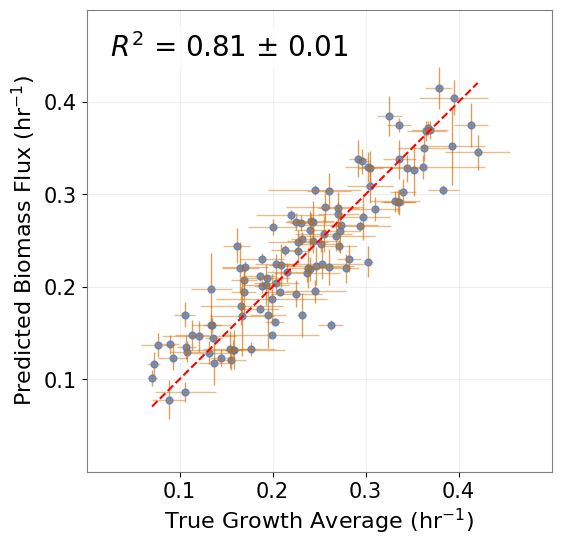

,repeat,carbon_count,R2,Pearson_r2,MAE,RMSE,NE
0,10,1,0.278274,0.428726,0.035024,0.040837,0.287254
1,10,2,0.835687,0.846775,0.025397,0.029395,0.137045
2,10,3,0.708163,0.735542,0.032200,0.037994,0.160266
3,10,4,0.664843,0.678102,0.037356,0.045533,0.156465
4,11,1,0.285795,0.566832,0.037572,0.040624,0.285754
5,11,2,0.789366,0.790638,0.028961,0.033282,0.155164
6,11,3,0.657577,0.673939,0.031834,0.041156,0.173601
7,11,4,0.744068,0.763833,0.034238,0.039789,0.136727
8,12,1,0.389225,0.549571,0.034423,0.037567,0.264254
9,12,2,0.751959,0.757746,0.031056,0.036116,0.168380


In [11]:
# Refresh an older kernel import without discarding trained results.
if not hasattr(ev, "summarize_amn_oof"):
    from importlib import reload
    ev = reload(ev)

if amn_result is not None:
    oof = amn_result["oof"]
    means, amn_scores, amn_spread = ev.summarize_amn_oof(
        oof, len(amn_data["ids"]), AMN_SETTINGS["split_seeds"])
    oof_true_cv = means.truth.to_numpy()
    oof_pred_cv = means.prediction.to_numpy()
    oof_std_cv = amn_data["growth_std"][means.index]
    oof_pred_seed_std_cv = means.prediction_std.to_numpy()
    r2_oof, r2_oof_std = amn_scores["R2"], amn_spread["R2"]
    line_min_cv = float(max(0.0, min(oof_true_cv.min(), oof_pred_cv.min())))
    line_max_cv = float(min(0.5, max(oof_true_cv.max(), oof_pred_cv.max())))

    def format_r2_with_std(r2_value, r2_std):
        std_precision = 3 if abs(float(r2_std)) < 0.005 else 2
        return f"$R^2$ = {r2_value:.2f} $\\pm$ {r2_std:.{std_precision}f}"

    amn_metric_summary = pd.DataFrame([
        {"Metric": key, "OOF score": amn_scores[key], "SD across repeats": amn_spread[key]}
        for key in ("R2", "MAE", "RMSE")])
    display(amn_metric_summary)
    amn_metric_summary.to_csv(run_dir / "amn/aggregated_oof_metrics.csv", index=False)

    plt.figure(figsize=(6, 6))
    plt.hlines(
        y=oof_pred_cv,
        xmin=oof_true_cv - oof_std_cv,
        xmax=oof_true_cv + oof_std_cv,
        colors="#CC6E00",
        alpha=0.45,
        linewidth=1.0,
    )
    plt.vlines(
        x=oof_true_cv,
        ymin=oof_pred_cv - oof_pred_seed_std_cv,
        ymax=oof_pred_cv + oof_pred_seed_std_cv,
        colors="#CC6E00",
        alpha=0.65,
        linewidth=1.0,
    )
    plt.scatter(oof_true_cv, oof_pred_cv, alpha=0.78, s=24, c="#3F7BD9")
    plt.plot([line_min_cv, line_max_cv], [line_min_cv, line_max_cv], "r--", lw=1.5)
    plt.xlabel(r"True Growth Average (hr$^{-1}$)", fontsize=16)
    plt.ylabel(r"Predicted Biomass Flux (hr$^{-1}$)", fontsize=16)
    #plt.title("Out-of-Fold True vs Predicted", fontsize=16)
    plt.xlim(0.0, 0.5)
    plt.ylim(0.0, 0.5)
    plt.text(0.05, 0.95, format_r2_with_std(r2_oof, r2_oof_std), transform=plt.gca().transAxes,
             ha="left", va="top", fontsize=20,
             bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.75))
    plt.xticks(np.arange(0.1, 0.5, 0.1), fontsize=15)
    plt.yticks(np.arange(0.1, 0.5, 0.1), fontsize=15)
    ax = plt.gca()
    for spine in ax.spines.values():
        spine.set_color("gray")
    plt.grid(alpha=0.2)
    plt.savefig(pic_dir / f"{model_name}_amn_growth.png", dpi=300, bbox_inches="tight")
    plt.show()
    carbon_metrics = pd.DataFrame([{"repeat": repeat, "carbon_count": count, **ev.metrics(part.truth, part.prediction)}
        for (repeat, count), part in oof.groupby(["repeat", "carbon_count"])])
    carbon_metrics.to_csv(run_dir / "amn/carbon_count_metrics.csv", index=False)
    display(carbon_metrics)
    means.to_csv(run_dir / "amn/mean_predictions.csv")


## MINN: prepare data and model C context

The primary fitted target file supplies both flux targets and observed glucose/oxygen feature values, preserving the maintained Table 4 workflow. The loader checks experiment IDs across all three files. The front MLP receives 141 features; 42 signed non-context targets train its latent controls. All 47 source fluxes are retained for downstream pFBA evaluation. Common base inputs are 50; cobalamin is 50 only for checkpoints that include it. Other carbon and amino-acid inputs are zero. The configured 40-input checkpoint excludes cobalamin.

Scaling is fitted inside each training fold. Observed glucose/oxygen are passed separately in physical units, so scaling cannot change copied reservoir bounds. Neither mode trains against exact context targets.

In [12]:
if RUN_MINN:
    for target_mode in TARGET_MODES:
        data = ev.load_minn(MINN_DIR, output_names, target_mode,
                            input_names=input_names, model_family=MODEL_FAMILY)
        minn_data[target_mode] = data
        print(target_mode, "features/targets:", data["X"].shape, data["y"].shape)
        mapping = pd.DataFrame(data["mapping"], columns=["source", "token", "sign"])
        display(mapping)
        mapping.to_csv(run_dir / f"{target_mode}_mapping.csv", index=False)
        ev.save_json(run_dir / f"{target_mode}_schema.json", {"features": data["features"],
            "targets": data["targets"], "samples": data["ids"].tolist(), "fixed": data["fixed"]})


minn_fitted features/targets: (29, 141) (29, 42)


,source,token,sign
0,R_GLCptspp,GLCptspp_flux,1.0
1,R_PGI_fwd,PGI_flux,1.0
2,R_PFK,PFK_flux,1.0
3,R_FBA_fwd,FBA_flux,1.0
4,R_TPI_fwd,TPI_flux,1.0
5,R_PGK_rev,PGK_flux,-1.0
6,R_GAPD_fwd,GAPD_flux,1.0
7,R_ENO_fwd,ENO_flux,1.0
8,R_PGM_rev,PGM_flux,-1.0
9,R_PYK,PYK_flux,1.0


### Train MINN MLP: measured glucose/oxygen context

Match model C: tune once with five-fold CV over the full MINN dataset (50 trials), then reuse the selected parameters for every leave-one-out fit. Each fit uses its held-out condition for early stopping and restores the best weights. This MLP predicts CO2, ethanol and acetate; observed glucose/O2 are copied into reservoir inputs.

Early stopping may be changed after the first notebook run. Full-dataset HPO and held-out-condition epoch selection follow the current C protocol and can make reported scores optimistic. FP32 remains the default following the reported AMP gradient failure.


In [13]:
if RUN_MINN:
    for target_mode, data in minn_data.items():
        minn_results[(target_mode, "measured")] = ev.run_minn(reservoir, output_names, data,
            "measured", MINN_SETTINGS, run_dir / "minn" / target_mode / "measured")


c:\Users\truok\projects\metabolic-NN\venv\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
c:\Users\truok\projects\metabolic-NN\venv\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  optuna_warn(
[I 2026-09-15 09:53:50,768] A new study created in memory with name: no-name-1e7896ba-20d2-46c1-bec4-fd76e47a5739
[I 2026-09-15 10:03:08,428] Trial 0 finished with value: 0.36005577648580184 and parameters: {'drop_rate': 0.4, 'learning_rate': 0.003538123595632612, 'weight_decay': 5.5530705063765935e-05}. Best is trial 0 with value: 0.36005577648580184.
[I 2026-09-15 10:09:41,331] Trial 1 finished with value: 0.36079318275196454 and parameters: {'drop_rate': 0.1, 'learning_rate': 0.005656664562602267, 'weight_decay': 0.00022955120063380515}. Best is trial 0 with val

MINN measured global best parameters: {'drop_rate': 0.3, 'learning_rate': 0.0005844206591521583, 'weight_decay': 3.212154907895402e-08}
MINN measured: 1/29, best epoch 17
MINN measured: 2/29, best epoch 5
MINN measured: 3/29, best epoch 21
MINN measured: 4/29, best epoch 24
MINN measured: 5/29, best epoch 6
MINN measured: 6/29, best epoch 10
MINN measured: 7/29, best epoch 7
MINN measured: 8/29, best epoch 6
MINN measured: 9/29, best epoch 13
MINN measured: 10/29, best epoch 13
MINN measured: 11/29, best epoch 13
MINN measured: 12/29, best epoch 33
MINN measured: 13/29, best epoch 87
MINN measured: 14/29, best epoch 40
MINN measured: 15/29, best epoch 14
MINN measured: 16/29, best epoch 7
MINN measured: 17/29, best epoch 18
MINN measured: 18/29, best epoch 30
MINN measured: 19/29, best epoch 29
MINN measured: 20/29, best epoch 7
MINN measured: 21/29, best epoch 13
MINN measured: 22/29, best epoch 7
MINN measured: 23/29, best epoch 8
MINN measured: 24/29, best epoch 13
MINN measured: 25

### Train a separate MINN MLP: predicted glucose/oxygen context

This mode independently predicts all five latent context values. It receives the same feature matrix and tuning budget as the measured mode. Observed glucose/O2 remain available as features and remain the downstream pFBA uptake bounds. Both modes are retained; the notebook does not select a winner using outer-test scores.

In [14]:
if RUN_MINN:
    for target_mode, data in minn_data.items():
        minn_results[(target_mode, "predicted")] = ev.run_minn(reservoir, output_names, data,
            "predicted", MINN_SETTINGS, run_dir / "minn" / target_mode / "predicted")


c:\Users\truok\projects\metabolic-NN\venv\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
c:\Users\truok\projects\metabolic-NN\venv\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  optuna_warn(
[I 2026-09-15 16:22:40,907] A new study created in memory with name: no-name-21061018-9462-4dc9-b957-1d1930e9e668
[I 2026-09-15 16:40:18,370] Trial 0 finished with value: 0.29593039228572826 and parameters: {'drop_rate': 0.4, 'learning_rate': 0.003538123595632612, 'weight_decay': 5.5530705063765935e-05}. Best is trial 0 with value: 0.29593039228572826.
[I 2026-09-15 16:55:47,049] Trial 1 finished with value: 0.28799155050746916 and parameters: {'drop_rate': 0.1, 'learning_rate': 0.005656664562602267, 'weight_decay': 0.00022955120063380515}. Best is trial 1 with val

MINN predicted global best parameters: {'drop_rate': 0.35, 'learning_rate': 0.007158686060179075, 'weight_decay': 2.999672169407527e-06}
MINN predicted: 1/29, best epoch 24
MINN predicted: 2/29, best epoch 1
MINN predicted: 3/29, best epoch 41
MINN predicted: 4/29, best epoch 28
MINN predicted: 5/29, best epoch 9
MINN predicted: 6/29, best epoch 10
MINN predicted: 7/29, best epoch 14
MINN predicted: 8/29, best epoch 25
MINN predicted: 9/29, best epoch 13
MINN predicted: 10/29, best epoch 29
MINN predicted: 11/29, best epoch 11
MINN predicted: 12/29, best epoch 6
MINN predicted: 13/29, best epoch 7
MINN predicted: 14/29, best epoch 41
MINN predicted: 15/29, best epoch 17
MINN predicted: 16/29, best epoch 3
MINN predicted: 17/29, best epoch 14
MINN predicted: 18/29, best epoch 63
MINN predicted: 19/29, best epoch 4
MINN predicted: 20/29, best epoch 98
MINN predicted: 21/29, best epoch 106
MINN predicted: 22/29, best epoch 4
MINN predicted: 23/29, best epoch 128
MINN predicted: 24/29, bes

### Direct MINN flux and context diagnostics

Regression R? and squared Pearson correlation (`Pearson_r2`) are separate columns. The latter preserves the historical Table 4-style correlation metric. Undefined constant-target R? or zero-denominator normalized error remains undefined. Measured-copy identity values are not reported as predictions.

,target_mode,context_mode,R2,Pearson_r2,MAE,RMSE,NE
0,minn_fitted,measured,0.808595,0.833316,0.473407,1.161643,0.407034
1,minn_fitted,predicted,0.911449,0.917146,0.380560,0.790117,0.276853


minn_fitted measured


,R2,Pearson_r2,MAE,RMSE,NE
mean,0.396762,0.931129,0.473407,0.772340,0.368662
<lambda>,2.665829,0.069553,0.432509,0.867701,0.614393


,flux,R2,Pearson_r2,MAE,RMSE,NE
9,PYK_flux,-3.324700,0.040546,1.587865,1.810565,0.996676
8,PGM_flux,0.522711,0.717430,1.029514,1.916525,0.320401
7,ENO_flux,0.539297,0.718443,0.997140,1.882929,0.314785
40,EX_for_e_flux,-24849.320995,0.269609,0.923317,4.318936,151.397461
2,PFK_flux,0.059794,0.379776,0.911404,1.600806,0.472353
3,FBA_flux,0.018570,0.307885,0.910454,1.635523,0.482597
23,SUCOAS_flux,0.518321,0.850109,0.768237,1.327050,0.417719
5,PGK_flux,0.757636,0.795073,0.742419,1.705599,0.240514
6,GAPD_flux,0.762709,0.792074,0.718483,1.687652,0.237983
27,MDH_flux,0.692561,0.863219,0.701490,0.910723,0.247682


,source,role,min,max,mean,observed_mean
0,R_EX_glc__D_e_rev,copied,2.763000,12.890100,3.880190,3.880190
1,R_EX_o2_e_rev,copied,6.020400,26.241699,9.602583,9.602583
2,R_EX_co2_e_fwd,latent prediction,3.643560,16.890331,10.726072,7.989683
3,R_EX_etoh_e,latent prediction,0.589911,3.719494,1.541516,0.011659
4,R_EX_ac_e,latent prediction,0.067575,0.966851,0.485356,0.083952


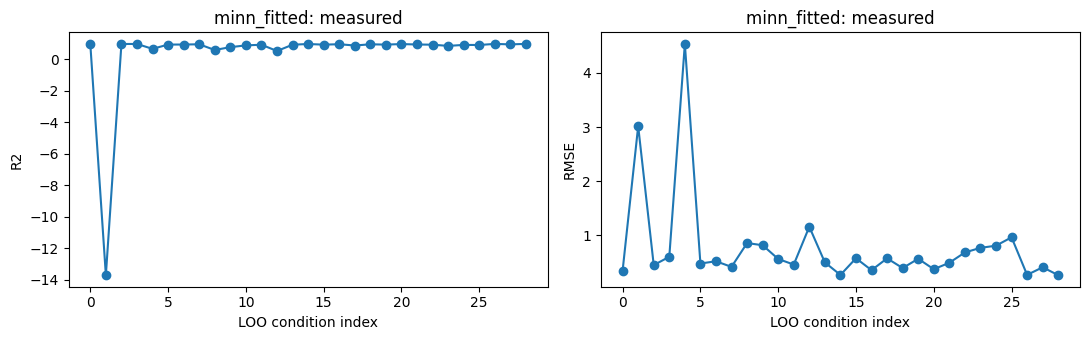

minn_fitted predicted


,R2,Pearson_r2,MAE,RMSE,NE
mean,0.885843,0.938202,0.380560,0.569579,0.236476
<lambda>,0.306376,0.076782,0.416616,0.547599,0.199113


,flux,R2,Pearson_r2,MAE,RMSE,NE
9,PYK_flux,-3.323028,0.004932,1.586934,1.810215,0.996483
2,PFK_flux,0.503821,0.882622,0.802629,1.162910,0.343142
3,FBA_flux,0.496215,0.867173,0.802515,1.171790,0.345762
27,MDH_flux,0.565106,0.802630,0.722398,1.083174,0.294582
23,SUCOAS_flux,0.551611,0.847486,0.677494,1.280370,0.403026
25,SUCDi_flux,0.617688,0.870134,0.599671,1.103093,0.321805
11,G6PDH2r_flux,0.041035,0.221542,0.571649,0.976190,0.729424
12,PGL_flux,0.080532,0.270810,0.561396,0.955876,0.714244
13,GND_flux,0.027744,0.185164,0.557306,0.968085,0.736680
26,FUM_flux,0.680500,0.868709,0.547736,0.974065,0.272728


,source,role,min,max,mean,observed_mean
0,R_EX_glc__D_e_rev,latent prediction,1.682022,8.895386,3.372168,3.880190
1,R_EX_o2_e_rev,latent prediction,1.226522,24.124535,12.120627,9.602583
2,R_EX_co2_e_fwd,latent prediction,0.926452,30.210703,12.844234,7.989683
3,R_EX_etoh_e,latent prediction,0.010126,56.853939,12.821572,0.011659
4,R_EX_ac_e,latent prediction,0.000022,1.702970,0.459632,0.083952


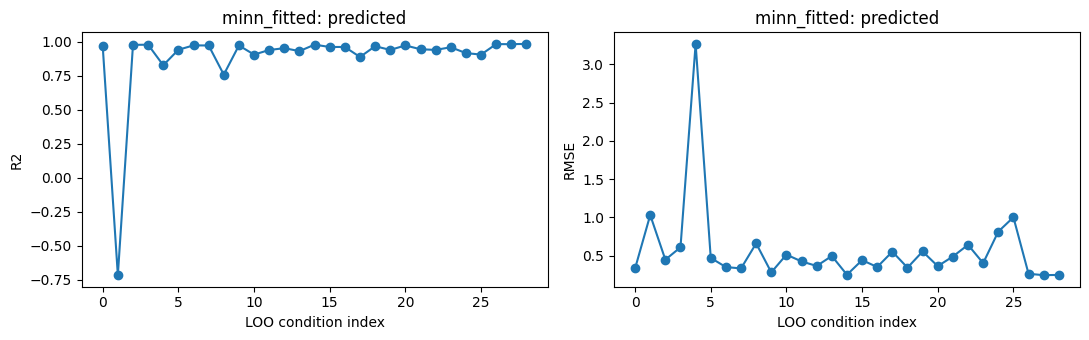

In [15]:
if RUN_MINN:
    direct_summary = pd.DataFrame([{"target_mode": target, "context_mode": mode, **result["pooled"]}
        for (target, mode), result in minn_results.items()])
    display(direct_summary)
    direct_summary.to_csv(run_dir / "minn_direct_summary.csv", index=False)
    for (target, mode), result in minn_results.items():
        print(target, mode)
        display(result["per_sample"].drop(columns="sample").agg(["mean", lambda x: x.std(ddof=0)]))
        display(result["per_flux"].sort_values("MAE", ascending=False).head(10))
        context_rows = []
        for j, source in enumerate(ev.CONTEXT_SOURCES):
            values = result["context"][:, j]
            context_rows.append({"source": source, "role": "copied" if mode == "measured" and j < 2 else "latent prediction",
                "min": values.min(), "max": values.max(), "mean": values.mean(),
                "observed_mean": minn_data[target]["context_truth"][:, j].mean()})
        display(pd.DataFrame(context_rows))
        pd.DataFrame(context_rows).to_csv(run_dir / "minn" / target / mode / "context_diagnostics.csv", index=False)
        fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
        for ax, metric in zip(axes, ["R2", "RMSE"]):
            ax.plot(result["per_sample"][metric].to_numpy(), "o-")
            ax.set(xlabel="LOO condition index", ylabel=metric, title=f"{target}: {mode}")
        fig.tight_layout()
        fig.savefig(pic_dir / f"{model_name}_{target}_{mode}_loo.png", dpi=180)
        plt.show()


## pFBA baseline and both reservoir-to-pFBA variants

All methods preserve the same iML1515 SBML background medium and core objective. Glucose/O2 are observed uptake lower-bound caps, not equality constraints. The reservoir's MINN input vector follows its pretraining base-50 contract; the downstream mechanistic baseline follows the maintained Table 4 SBML medium. The downstream pFBA fraction is 1.0, matching model C. OOF CO2/ethanol/acetate predictions become nonnegative secretion upper caps. Every sample retains a solver status.

In [16]:
if RUN_MINN:
    for target, data in minn_data.items():
        pfba_results[target] = {"baseline": ev.run_pfba(XML_PATH, data, fraction=PFBA_FRACTION)}
        display(pfba_results[target]["baseline"]["status"])


,sample,status,error
0,REF,optimal,
1,WT_0.1h-1,optimal,
2,WT_0.4h-1,optimal,
3,WT_0.5h-1,optimal,
4,WT_0.7h-1,optimal,
5,galM,optimal,
6,glk,optimal,
7,pgm,optimal,
8,pgi,optimal,
9,pfkA,optimal,


In [17]:
if RUN_MINN:
    for target, data in minn_data.items():
        for cap_mode in CAP_MODES:
            pfba_results[target][f"measured_{cap_mode}"] = ev.run_pfba(XML_PATH, data,
                minn_results[(target, "measured")]["context"], cap_mode, PFBA_FRACTION)


In [18]:
if RUN_MINN:
    for target, data in minn_data.items():
        for cap_mode in CAP_MODES:
            pfba_results[target][f"predicted_{cap_mode}"] = ev.run_pfba(XML_PATH, data,
                minn_results[(target, "predicted")]["context"], cap_mode, PFBA_FRACTION)


### Compare methods and diagnose binding caps

Report all successes and an explicitly matched common-success subset. Optional cap-set sensitivities are compared separately so their failures cannot change the primary three-method subset. The full 47-flux and non-context-only metric sets are exported. Negative paired MAE change means improvement over baseline. `binding_low_cap` marks a binding secretion cap below its fitted target.

In [19]:
pfba_tables = {}
if RUN_MINN:
    for target, data in minn_data.items():
        for cap_mode in CAP_MODES:
            selected = {key: pfba_results[target][key] for key in
                ("baseline", f"measured_{cap_mode}", f"predicted_{cap_mode}")}
            table = ev.compare_pfba(selected, data, run_dir / "pfba" / target / cap_mode)
            pfba_tables[(target, cap_mode)] = table
            display(table.query("coverage == 'common_success' and targets == 'all'"))
            for method, result in selected.items():
                failed = result["status"].query("status != 'optimal'")
                if len(failed):
                    print(target, method, "failed solves:")
                    display(failed)
                if not result["caps"].empty:
                    print(target, method, "binding caps:")
                    display(result["caps"].sort_values(["binding_low_cap", "slack"], ascending=[False, True]).head(12))


,method,coverage,targets,successes,total,metric,defined,mean,std
10,baseline,common_success,all,29,29,R2,29,0.688092,1.026816
11,baseline,common_success,all,29,29,Pearson_r2,29,0.892120,0.129929
12,baseline,common_success,all,29,29,MAE,29,0.498595,0.362444
13,baseline,common_success,all,29,29,RMSE,29,0.830279,0.600741
14,baseline,common_success,all,29,29,NE,29,0.305834,0.345503
30,measured_co2_etoh_ac_cap,common_success,all,29,29,R2,29,0.729307,0.835105
31,measured_co2_etoh_ac_cap,common_success,all,29,29,Pearson_r2,29,0.899712,0.120173
32,measured_co2_etoh_ac_cap,common_success,all,29,29,MAE,29,0.475725,0.415896
33,measured_co2_etoh_ac_cap,common_success,all,29,29,RMSE,29,0.841987,0.816956
34,measured_co2_etoh_ac_cap,common_success,all,29,29,NE,29,0.290384,0.313225


minn_fitted measured_co2_etoh_ac_cap binding caps:


,sample,source,cap,flux,target,slack,binding,binding_low_cap
12,WT_0.7h-1,R_EX_co2_e_fwd,14.749499,14.749499,19.6169,0.0,True,True
75,tktA,R_EX_co2_e_fwd,11.249692,11.249692,11.4681,0.0,True,True
3,WT_0.1h-1,R_EX_co2_e_fwd,3.643560,3.643560,0.8565,0.0,True,False
5,WT_0.1h-1,R_EX_ac_e,0.433230,0.433230,0.0000,0.0,True,False
6,WT_0.4h-1,R_EX_co2_e_fwd,11.430591,11.430591,10.8751,0.0,True,False
8,WT_0.4h-1,R_EX_ac_e,0.655367,0.655367,0.0100,0.0,True,False
9,WT_0.5h-1,R_EX_co2_e_fwd,14.375201,14.375201,12.7317,0.0,True,False
11,WT_0.5h-1,R_EX_ac_e,0.907738,0.907738,0.4896,0.0,True,False
20,glk,R_EX_ac_e,0.177760,0.177760,0.0000,0.0,True,False
23,pgm,R_EX_ac_e,0.140149,0.140149,0.0000,0.0,True,False


minn_fitted predicted_co2_etoh_ac_cap binding caps:


,sample,source,cap,flux,target,slack,binding,binding_low_cap
11,WT_0.5h-1,R_EX_ac_e,0.000022,0.000022,0.4896,0.0,True,True
14,WT_0.7h-1,R_EX_ac_e,0.260997,0.260997,1.9350,0.0,True,True
3,WT_0.1h-1,R_EX_co2_e_fwd,0.926452,0.926452,0.8565,0.0,True,False
5,WT_0.1h-1,R_EX_ac_e,0.463474,0.463474,0.0000,0.0,True,False
20,glk,R_EX_ac_e,0.139522,0.139522,0.0000,0.0,True,False
23,pgm,R_EX_ac_e,0.295310,0.295310,0.0000,0.0,True,False
26,pgi,R_EX_ac_e,0.401992,0.401992,0.0000,0.0,True,False
35,fbp,R_EX_ac_e,0.254349,0.254349,0.0000,0.0,True,False
38,fbaB,R_EX_ac_e,1.104951,1.104951,0.0000,0.0,True,False
47,gpmB,R_EX_ac_e,0.039566,0.039566,0.0000,0.0,True,False


## Completion and exports

AMN growth, direct MINN flux predictions and pFBA flux predictions are separate outcomes. A smaller direct-flux error need not produce better pFBA caps. Skipped optional sections are recorded separately; failed requested runs qualify completeness; no results are copied from historical checkpoints. Each MLP fit, fold assignment, selected epoch count, context prediction and solver status is stored under this run's directory.

In [20]:
completion = {"amn": False, "minn_both_modes": False, "pfba_all_successful": False,
              "simulated_A_B": simulated_summary is not None}
if amn_result is not None:
    completion["amn"] = len(amn_result["oof"]) == 110 * len(AMN_SETTINGS["split_seeds"])
if RUN_MINN:
    completion["minn_both_modes"] = all((target, mode) in minn_results and
        len(minn_results[(target, mode)]["prediction"]) == 29 for target in TARGET_MODES for mode in ("measured", "predicted"))
    completion["pfba_all_successful"] = all(result["success"].all()
        for methods in pfba_results.values() for result in methods.values())
manifest["completion"] = completion
requested_checks = ([completion["amn"]] if RUN_AMN else [])
requested_checks += [completion["minn_both_modes"], completion["pfba_all_successful"]] if RUN_MINN else []
requested_checks += [completion["simulated_A_B"]] if RUN_SIMULATED else []
manifest["status"] = "complete" if requested_checks and all(requested_checks) else "incomplete_or_qualified"
manifest["skipped"] = [name for name, enabled in [("amn", RUN_AMN), ("minn", RUN_MINN), ("full_simulated_A_B", RUN_SIMULATED)] if not enabled]
manifest["finished_utc"] = datetime.now(timezone.utc).isoformat()
ev.save_json(run_dir / "manifest.json", manifest)
display(pd.DataFrame([completion]))
print("Run status:", manifest["status"])
print("Results:", run_dir)
print("Register actual checkpoint/provenance and matched results in docs/experiment_notes/iML1515_sampling_study_notes.md.")


,amn,minn_both_modes,pfba_all_successful,simulated_A_B
0,True,True,True,False


Run status: complete
Results: c:\Users\truok\projects\metabolic-NN\pics\AMN_MINN_1M_d256_h8_l4_ff1024\C_evaluation\20260915T024826709856Z
Register actual checkpoint/provenance and matched results in docs/experiment_notes/iML1515_sampling_study_notes.md.


In [21]:
# Refresh an older kernel import without discarding trained results.
if not hasattr(ev, "summarize_amn_oof"):
    from importlib import reload
    ev = reload(ev)

# Final experimental evaluation summary (OOF predictions only).
summary_rows = []
metric_names = ("R2", "MAE", "RMSE")


def experimental_summary_row(dataset, method, truth, prediction, target_names, total):
    truth, prediction = np.asarray(truth), np.asarray(prediction)
    valid = np.isfinite(truth).all(axis=1) & np.isfinite(prediction).all(axis=1)
    row = {"Dataset": dataset, "Method": method, "Samples": f"{int(valid.sum())}/{total}",
           "Pooled targets": len(target_names), "Aggregation": "All available OOF samples"}
    values = {key: np.nan for key in metric_names}
    if valid.any():
        values = ev.metrics(truth[valid], prediction[valid])
    row.update({f"Pooled {key}": values[key] for key in metric_names})
    return row


if amn_result is not None:
    means, amn_scores, amn_spread = ev.summarize_amn_oof(
        amn_result["oof"], len(amn_data["ids"]), AMN_SETTINGS["split_seeds"])
    row = experimental_summary_row("AMN", "Frozen reservoir + AMN MLP",
        means[["truth"]].to_numpy(), means[["prediction"]].to_numpy(),
        amn_data["targets"], len(amn_data["ids"]))
    row["Aggregation"] = "Per-medium mean OOF predictions (model C convention)"
    summary_rows.append(row)

for (target_mode, context_mode), result in minn_results.items():
    data = minn_data[target_mode]
    summary_rows.append(experimental_summary_row(f"MINN ({target_mode})",
        f"Direct reservoir: {context_mode} glucose/O2", data["y"], result["prediction"],
        data["targets"], len(data["ids"])))

for target_mode, methods in pfba_results.items():
    data = minn_data[target_mode]
    for method, result in methods.items():
        summary_rows.append(experimental_summary_row(f"MINN ({target_mode})",
            "pFBA baseline" if method == "baseline" else f"Reservoir to pFBA: {method}",
            result["truth"], result["prediction"],
            result["names"], len(data["ids"])))

experimental_summary = pd.DataFrame(summary_rows)
print("EXPERIMENTAL DATA - pooled flux accuracy")
print("AMN pooling covers its single measured growth target.")
print("MINN direct pooling uses non-context targets; pFBA pooling uses all mapped targets.")
print("R2 is regression R-squared. Pooled scores flatten samples and fluxes; they are not mean per-sample scores.")
print("Failed/nonfinite predictions are excluded explicitly in Samples; compare methods with matching coverage.")
if experimental_summary.empty:
    print("No experimental results available. Run the AMN and/or MINN evaluation cells first.")
else:
    numeric_columns = [f"Pooled {key}" for key in metric_names]
    experimental_summary = experimental_summary[["Dataset", "Method", "Samples", "Pooled targets", "Aggregation"] + numeric_columns]
    display(experimental_summary.style.format({column: "{:.4f}" for column in numeric_columns}, na_rep="undefined").hide(axis="index"))
    experimental_summary.to_csv(run_dir / "experimental_final_summary.csv", index=False)
    if amn_result is None:
        print("AMN evaluation has not been run.")
    for target_mode in TARGET_MODES:
        missing_modes = [mode for mode in ("measured", "predicted") if (target_mode, mode) not in minn_results]
        if missing_modes:
            print(f"MINN {target_mode}: missing context runs: {', '.join(missing_modes)}")


EXPERIMENTAL DATA - pooled flux accuracy
AMN pooling covers its single measured growth target.
MINN direct pooling uses non-context targets; pFBA pooling uses all mapped targets.
R2 is regression R-squared. Pooled scores flatten samples and fluxes; they are not mean per-sample scores.
Failed/nonfinite predictions are excluded explicitly in Samples; compare methods with matching coverage.


Dataset,Method,Samples,Pooled targets,Aggregation,Pooled R2,Pooled MAE,Pooled RMSE
AMN,Frozen reservoir + AMN MLP,110/110,1,Per-medium mean OOF predictions (model C convention),0.8125,0.0303,0.0365
MINN (minn_fitted),Direct reservoir: measured glucose/O2,29/29,42,All available OOF samples,0.8086,0.4734,1.1616
MINN (minn_fitted),Direct reservoir: predicted glucose/O2,29/29,42,All available OOF samples,0.9114,0.3806,0.7901
MINN (minn_fitted),pFBA baseline,29/29,47,All available OOF samples,0.8601,0.4986,1.0248
MINN (minn_fitted),Reservoir to pFBA: measured_co2_etoh_ac_cap,29/29,47,All available OOF samples,0.8167,0.4757,1.1732
MINN (minn_fitted),Reservoir to pFBA: predicted_co2_etoh_ac_cap,29/29,47,All available OOF samples,0.8755,0.4665,0.9667
